# Exec/Idle 耗时分布

数据来自 `exec_stats.csv`（client 退出时在运行目录导出，每 worker 的原始样本 `wid,idx,exec_us,idle_us`）。

下面把绘图逻辑封装成 `plot()` 函数，直接调用即可：idle / exec、只看某 worker、保存 png、将来 csv 加 `node_id` 列后可画 worker×节点 分面。

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def plot(csv, metric="idle", png=None, wid=None, by_node=False, q=0.99):
    """读 exec_stats.csv 画每 worker 的 exec/idle 耗时分布（violin + range line + P99/mean/min 标注）。

    参数
    ----
    csv      : 路径。列应为 wid,idx,exec_us,idle_us；若含 node_id 列 + by_node=True
               则按 worker×节点 分面（每 worker 一子图，x=节点）。
    metric   : 画哪列，"idle"（默认）或 "exec"。
    png      : 不 None → 保存到该路径（并关闭显示）；Jupyter 里不传 → 内联显示。
    wid      : 只画该 worker（int，None=全部）。
    by_node  : 有 node_id 列时按节点分组（仅 exec 有意义，idle 是 worker 级空档）。
    q        : 分布截断分位（默认 0.99，砍掉离群尾巴避免把坐标轴拉爆）。

    返回
    ----
    fig      : 可直接继续修饰；Jupyter 里直接 plot(...) 即显示。
    """
    df = pd.read_csv(csv)
    if wid is not None:
        df = df[df["wid"] == wid]
    has_node = "node_id" in df.columns
    col = {"exec": "exec_us", "idle": "idle_us"}[metric]

    cols = ["wid", col]
    if has_node and by_node:
        cols.append("node_id")
    d = df[cols].rename(columns={col: "us"})
    d = d[d["us"] > 0]
    if d.empty:
        print(f"[plot] {csv}: no positive {metric} samples")
        return None

    cap = d["us"].quantile(q)
    d_cut = d[d["us"] <= cap]

    sns.set_theme(style="whitegrid")

    if has_node and by_node:
        # worker × 节点：每 worker 一子图，x=节点，看 exec 分布差异
        g = sns.FacetGrid(d_cut, col="wid", height=4)
        g.map_dataframe(sns.violinplot, x="node_id", y="us", cut=0, inner="box")
        g.set_axis_labels("node id", f"{metric} time (us)")
        g.fig.subplots_adjust(top=0.88)
        g.fig.suptitle(f"per-worker × per-node {metric} (P{q:.0%} cap)")
        fig = g.fig
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.violinplot(data=d_cut, x="wid", y="us", hue="wid", legend=False,
                       palette="Set2", cut=0, inner=None, linewidth=0, ax=ax)
        ax.set_ylabel(f"{metric} time (us)")
        ax.set_title(f"per-worker {metric} distribution (P{q:.0%}, linear)")
        n_wid = len(d["wid"].unique())
        ax.set_xlim(-0.4, n_wid - 0.6)
        # range line（min→P99 竖线）+ P99/mean/min 短刻度与对齐标注
        for xpos, w in enumerate(d["wid"].unique()):
            sub = d.loc[d["wid"] == w, "us"]
            mn, mean, p99 = sub.min(), sub.mean(), sub.quantile(0.99)
            vx = xpos
            ax.plot([vx, vx], [mn, p99], color="0.35", lw=1.0)
            for val in (p99, mean, mn):
                ax.plot([vx - 0.02, vx + 0.02], [val, val], color="0.35", lw=1.2)
                ax.text(vx + 0.09, val, f"{val:.1f}", ha="left", va="center",
                        fontsize=8, family="monospace")
        ax.set_ylim(0, cap * 1.15)

    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150)
        print("saved:", png)
        plt.close(fig)
    return fig

saved: chain_2.png


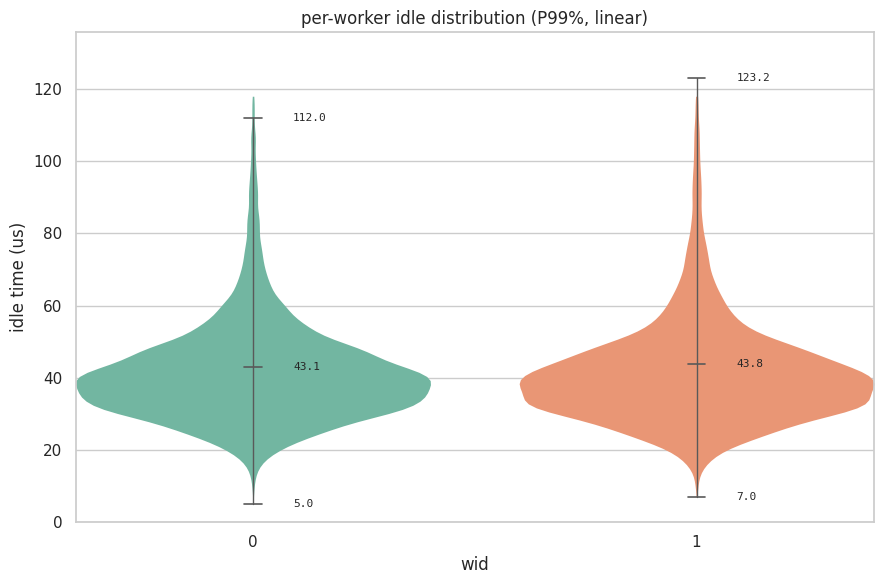

In [5]:
csv_chain_2 = "exec_stats_chain_2.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")
# plot(csv, "exec")                        # exec 分布
# plot(csv, "exec", wid=0)                 # 只看 worker 0
# plot(csv, png="exec_stats.png")         # 保存 png
# plot(csv, "exec", by_node=True)         # 等 csv 加 node_id 列后：worker×节点 分面

saved: chain_2.png


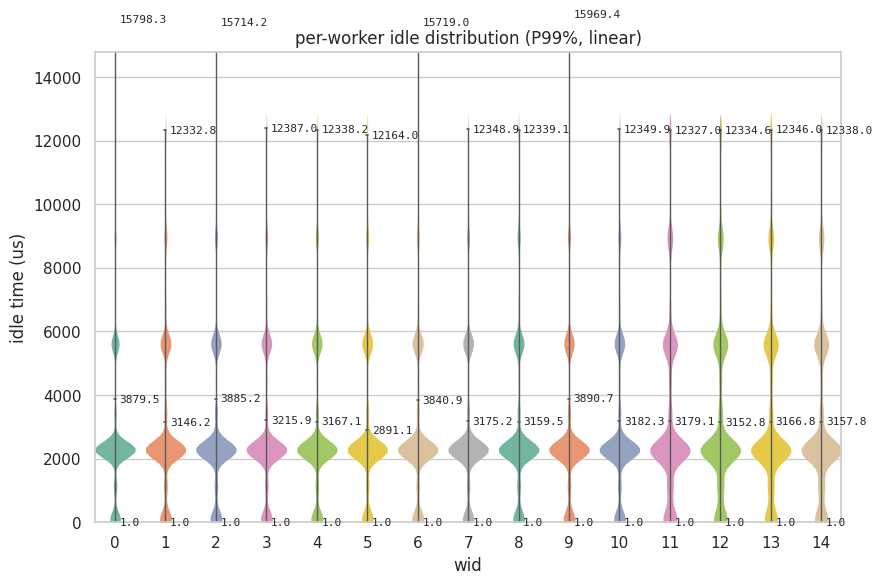

In [6]:
csv_chain_2 = "exec_stats_1.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

saved: chain_2.png


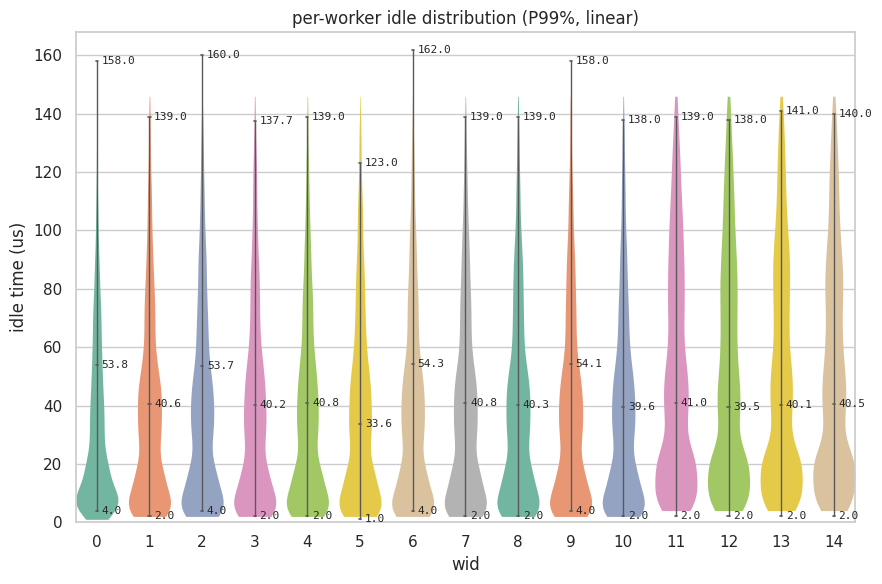

In [12]:
csv_chain_2 = "exec_stats_join10_t15_rt.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

saved: chain_2.png


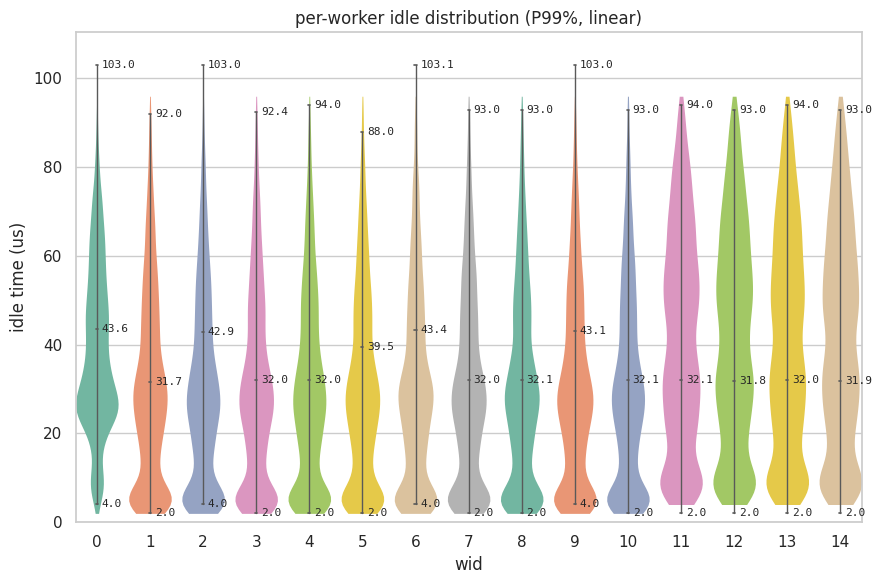

In [13]:
csv_chain_2 = "exec_stats_join_t15_rt.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

In [ ]:
csv_chain_2 = "exec_stats_5.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

In [ ]:
csv_chain_2 = "exec_stats_7.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

In [ ]:
csv_chain_2 = "exec_stats_8.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2, png="chain_2.png")

In [ ]:
csv_chain_2_new = "exec_stats_chain_2_new.csv"   # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_2_new, png="chain_2_new.png")

In [ ]:
csv_chain_10 = "exec_stats_chain_10.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_10, png = "chain_10.png")

In [ ]:
csv_chain_100 = "exec_stats_chain_100.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_10, png = "chain_100.png")

In [ ]:
csv_chain_100_new = "exec_stats_chain_100_new.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_chain_100_new, png = "chain_100_new.png")

In [ ]:
csv_fork_2 = "exec_stats_fork_2.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_fork_2, png = "fork_2.png")

In [ ]:
csv_fork_10 = "exec_stats_fork_10.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_fork_10, png = "fork_10.png")

In [ ]:
csv_fork_100_new = "exec_stats_fork_100_new.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_fork_100_new, png = "fork_100_new.png")

In [ ]:
csv_join_2 = "exec_stats_join_2.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t5_before_notify.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t5_after_notify.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t5_after_notify_linux.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t5_before_notify_linux.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t15_before_notify_linux.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_2 = "exec_stats_join10_t15_after_notify_linux.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_2, png = "join_2.png")

In [ ]:
csv_join_10 = "exec_stats_join_10.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_10, png = "join_10.png")

In [ ]:
csv_join10_t10 = "exec_stats_join10_t10.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t10, png = "join10_t10.png")

In [ ]:
csv_join10_t10 = "exec_stats_join10_t10_before_notify.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t10, png = "join10_t10.png")

In [ ]:
csv_join10_t10 = "exec_stats_join10_t10_after_notify.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t10, png = "join10_t10.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15_fake.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15_fake2.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15_notify.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15_real.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join10_t15 = "exec_stats_join10_t15_fake4.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join10_t15, png = "join10_t15.png")

In [ ]:
csv_join_100_new = "exec_stats_join_100.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join_100_new, png = "join_100_new.png")

In [ ]:
csv_join100_t1 = "exec_stats_join100_t1.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join100_t1, png = "join100_t1.png")

In [ ]:
csv_join100_t10 = "exec_stats_join100_t10.csv"  # 改成你的 csv 路径（client 退出时在运行目录生成）
plot(csv_join100_t10, png = "join100_t10.png")